In [53]:
!pip install seaborn
!pip install  scikit-learn

  Using cached scikit_learn-1.6.1-cp313-cp313-macosx_12_0_arm64.whl.metadata (31 kB)
  Using cached joblib-1.4.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached threadpoolctl-3.5.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.6.1-cp313-cp313-macosx_12_0_arm64.whl (11.1 MB)
Using cached joblib-1.4.2-py3-none-any.whl (301 kB)
Using cached threadpoolctl-3.5.0-py3-none-any.whl (18 kB)


In [1]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from sklearn.preprocessing import StandardScaler


In [2]:
def load_data(directory):
    data = []
    print( os.listdir(directory))
    files = glob.glob(directory + '/**/*.json', recursive=True)
    for filename in files:
        # files = glob.glob(directory + '/**/*.json', recursive=True)
        # print(files)
        # if filename.endswith('.json'):
        if "obj.json" in filename:
            with open(filename, 'r') as file:
                data.append(json.load(file))
    return data


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def extract_features(data):
    masses = []
    velocities = []
    accelerations = []
    angular_velocities = []
    angular_accelerations = []
    frictions = []
    densities = []
    elasticities = []

    # Dictionary to store previous dynamic features for each object id
    prev_info = {}

    for item in data:
        objects = item.get("objects", [])
        
        # Dynamic features from the "frames" list
        frames = item.get("frames", [])
        for frame in frames:
            time_current = frame['time']
    
            # Here, frame['objects'] is assumed to be a dictionary keyed by object id
            for obj_id, obj in frame['objects'].items():
                # Calculate current velocity magnitude
                current_velocity = np.linalg.norm(obj.get('velocity', []))
                velocities.append(current_velocity)
                # Calculate current angular velocity magnitude
                current_ang_vel = np.linalg.norm(obj.get('angular_velocity', []))
                angular_velocities.append(current_ang_vel)
                
                # Compute acceleration if previous data exists for this object
                if obj_id in prev_info:
                    prev_time, prev_vel, prev_ang_vel = prev_info[obj_id]
                    dt = time_current - prev_time
                    if dt > 0:
                        acc = np.linalg.norm((current_velocity - prev_vel) / dt)
                        ang_acc = np.linalg.norm((current_ang_vel - prev_ang_vel) / dt)
                        accelerations.append(acc)
                        angular_accelerations.append(ang_acc)
                # Update previous info for this object
                prev_info[obj_id] = (time_current, current_velocity, current_ang_vel)
            
            for obj in objects:
                masses.append(obj.get('mass'))
                # frictions.extend([obj.get('frictions')] * diff)
                # densities.extend([obj.get('densities')] * diff)
                # elasticities.extend([obj.get('elasticities')] * diff)
                frictions.append(float(obj.get('friction', 0)))
                densities.append(obj.get('density'))
                elasticities.append(obj.get('elasticity'))

        # curr_len = len(masses)
        # new_len = len(velocities)
        # diff = new_len - curr_len
        # print(diff)
        # Persistent features from the "objects" list
       
        # for obj in objects:
        #     masses.extend([obj.get('mass')] * diff)
        #     frictions.extend([obj.get('frictions')] * diff)
        #     densities.extend([obj.get('densities')] * diff)
        #     elasticities.extend([obj.get('elasticities')] * diff)
        #     # frictions.append(float(obj.get('friction', 0)))
        #     # densities.append(obj.get('density'))
        #     # elasticities.append(obj.get('elasticity'))
    return {
        "masses": masses,
        "velocities": velocities,
        "accelerations": accelerations,
        "angular_velocities": angular_velocities,
        "angular_accelerations": angular_accelerations,
        "frictions": frictions,
        "densities": densities,
        "elasticities": elasticities
    }        
    # return (masses, velocities, accelerations, angular_velocities,
    #         angular_accelerations, frictions, densities, elasticities)

def plot_distribution(data, title, y_label, x_label,  kde=True):
    color = np.random.choice(["blue", "green", "purple", "orange", "brown", "pink", "red", "yellow"])
    sns.histplot(data, kde=kde, color=color)
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.show()


In [4]:
directory = 'generated'
data = load_data(directory)
# datas

# masses, velocities, accelerations, frictions, densities, elasticities = extract_features(data)


['61', '95', '59', '92', '66', '50', '68', '57', '32', '35', '69', '56', '51', '58', '67', '93', '94', '60', '34', '33', '20', '18', '27', '9', '0', '11', '7', '29', '16', '42', '89', '45', '73', '87', '80', '74', '6', '28', '17', '1', '10', '19', '26', '8', '21', '75', '81', '86', '72', '44', '43', '88', '38', '36', '31', '91', '65', '62', '96', '54', '98', '53', '30', '37', '39', '99', '52', '55', '97', '63', '64', '90', '46', '79', '41', '83', '77', '48', '70', '84', '24', '23', '4', '15', '3', '12', '85', '71', '76', '82', '49', '40', '47', '78', '2', '13', '5', '14', '22', '25']


In [5]:
extracted_data = extract_features(data)
masses = extracted_data["masses"]
velocities = extracted_data["velocities"]
accelerations = extracted_data["accelerations"]
angular_velocities = extracted_data["angular_velocities"]
frictions = extracted_data["frictions"]
densities = extracted_data["densities"]
elasticities = extracted_data["elasticities"]


In [6]:
len(masses), len(velocities), len(accelerations), len(frictions), len(elasticities)

(101430, 101430, 100625, 101430, 101430)

In [7]:
masses

[0.3377631281761721,
 28.021767917373815,
 1.9613393195060007,
 1.6664268878096389,
 0.5373098947009962,
 2.2047041385934976,
 1.177431024513638,
 0.3829959379979602,
 2.9644961284366627,
 0.3377631281761721,
 28.021767917373815,
 1.9613393195060007,
 1.6664268878096389,
 0.5373098947009962,
 2.2047041385934976,
 1.177431024513638,
 0.3829959379979602,
 2.9644961284366627,
 0.3377631281761721,
 28.021767917373815,
 1.9613393195060007,
 1.6664268878096389,
 0.5373098947009962,
 2.2047041385934976,
 1.177431024513638,
 0.3829959379979602,
 2.9644961284366627,
 0.3377631281761721,
 28.021767917373815,
 1.9613393195060007,
 1.6664268878096389,
 0.5373098947009962,
 2.2047041385934976,
 1.177431024513638,
 0.3829959379979602,
 2.9644961284366627,
 0.3377631281761721,
 28.021767917373815,
 1.9613393195060007,
 1.6664268878096389,
 0.5373098947009962,
 2.2047041385934976,
 1.177431024513638,
 0.3829959379979602,
 2.9644961284366627,
 0.3377631281761721,
 28.021767917373815,
 1.961339319506000

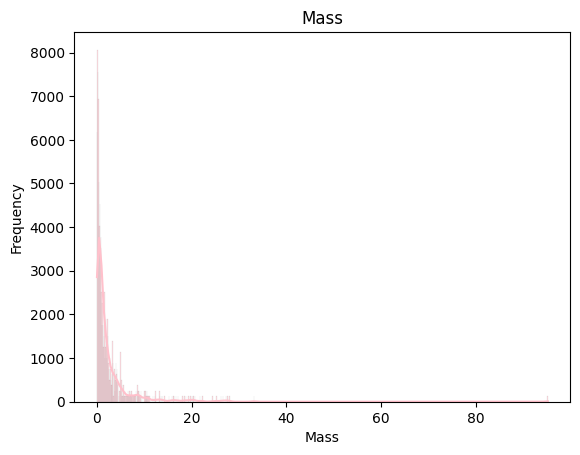

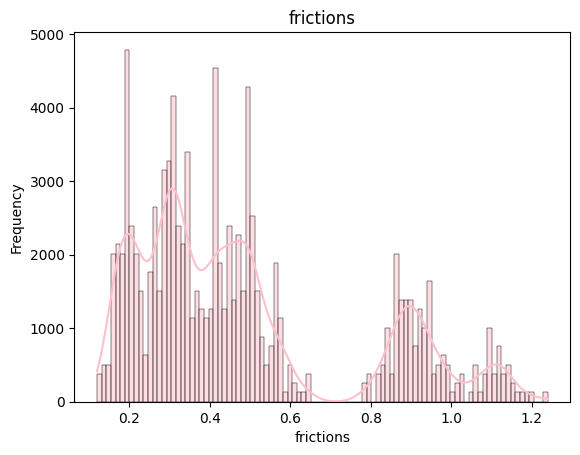

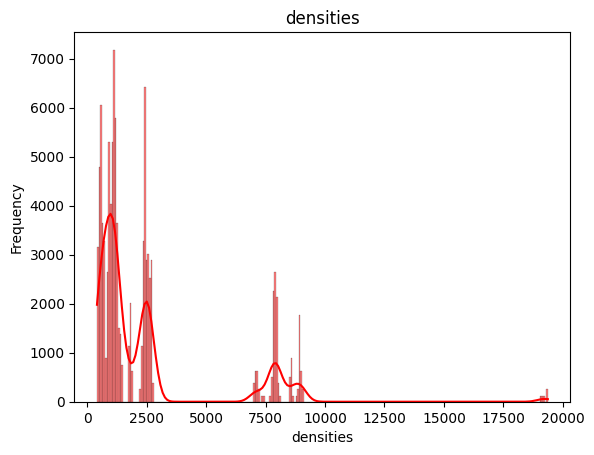

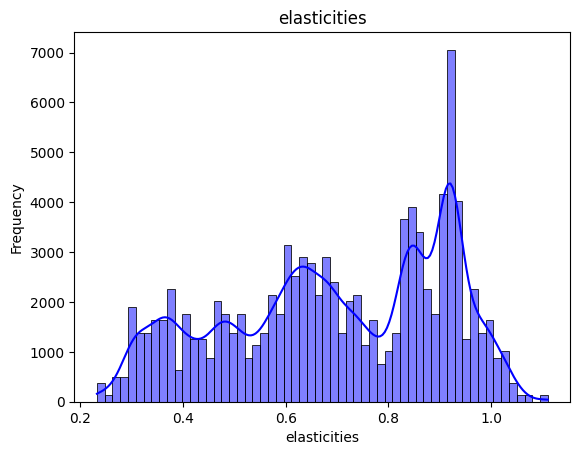

In [8]:
# plt.subplot(1, 2, 1)
plot_distribution(masses, "Mass", "Frequency", "Mass")
# plt.subplot(1, 2, 2)
# plt.tight_layout()
plot_distribution(frictions, "frictions", "Frequency", "frictions")
plot_distribution(densities, "densities", "Frequency", "densities")
plot_distribution(elasticities, "elasticities", "Frequency", "elasticities")


In [10]:
velocities

[np.float64(4.127211769199744),
 np.float64(0.0049050000000000005),
 np.float64(0.0049050000000000005),
 np.float64(1.1663721589946054),
 np.float64(1.7474601383222272),
 np.float64(3.8542682874347833),
 np.float64(3.1398571376046087),
 np.float64(1.3177140669254388),
 np.float64(2.846610143072852),
 np.float64(3.7347054988548014),
 np.float64(0.07655876614210967),
 np.float64(0.03544075184028047),
 np.float64(0.7995593493596487),
 np.float64(1.423189702648727),
 np.float64(3.5937518152094987),
 np.float64(3.054109108131605),
 np.float64(1.2241149130529219),
 np.float64(2.764986446324931),
 np.float64(3.4291566145092625),
 np.float64(0.07791141193152833),
 np.float64(0.015466790764106843),
 np.float64(0.6979092390884836),
 np.float64(1.1112303526551313),
 np.float64(3.405936831829714),
 np.float64(2.956120066874047),
 np.float64(1.1047372359101617),
 np.float64(2.68783302793434),
 np.float64(3.0653421895531836),
 np.float64(0.07792989232213055),
 np.float64(0.003375673948081826),
 np.f

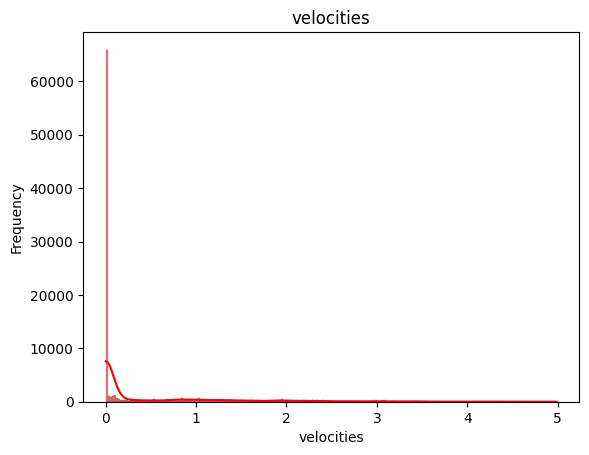

In [11]:
plot_distribution(velocities, "velocities", "Frequency", "velocities")
# plot_distribution(accelerations, "accelerations", "Frequency", "accelerations", kde=False)

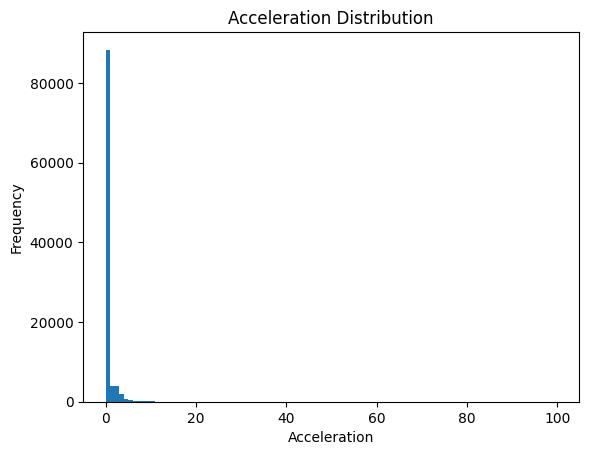

In [12]:
filtered_accelerations = [a for a in accelerations if abs(a) < 100]
len(accelerations), len(filtered_accelerations)


plt.hist(accelerations, bins=100)
plt.title("Acceleration Distribution")
plt.xlabel("Acceleration")
plt.ylabel("Frequency")
plt.show()


In [13]:

def analyze_data(input_data, use_correlation=False, scale_data=False):

    extracted_features = extract_features(input_data)

    data = {k: v for k, v in extracted_features.items() if v}
    # print(data)
    max_length = max(len(data[key]) for key in data)
    print("max_length", max_length)
    # Pad shorter lists with NaN to match the maximum length
    for key in data:
        print("key", key)
        # print(len(data[key]))
        # print(data[key][-10:])
        if len(data[key]) < max_length:
            print(len(data[key]))
            # data[key].extend(data[key] * (max_length - len(data[key])))
            while len(data[key]) < max_length:
                data[key].append(np.nan)


    df = pd.DataFrame(data)
    df = df.dropna() 

    if scale_data:
        scaler = StandardScaler()
        df = pd.DataFrame(scaler.fit_transform(df), columns = df.columns) # Scale data

    if use_correlation:
        matrix = df.corr(method='pearson') 
        title = 'Correlation Matrix of Physical Properties'
    else:
        matrix = df.cov()
        title = 'Covariance Matrix of Physical Properties'

    plt.figure(figsize=(12, 10))
    sns.heatmap(matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title(title)
    plt.show()



max_length 101430
key masses
key velocities
key accelerations
100625
key angular_velocities
key angular_accelerations
100625
key frictions
key densities
key elasticities


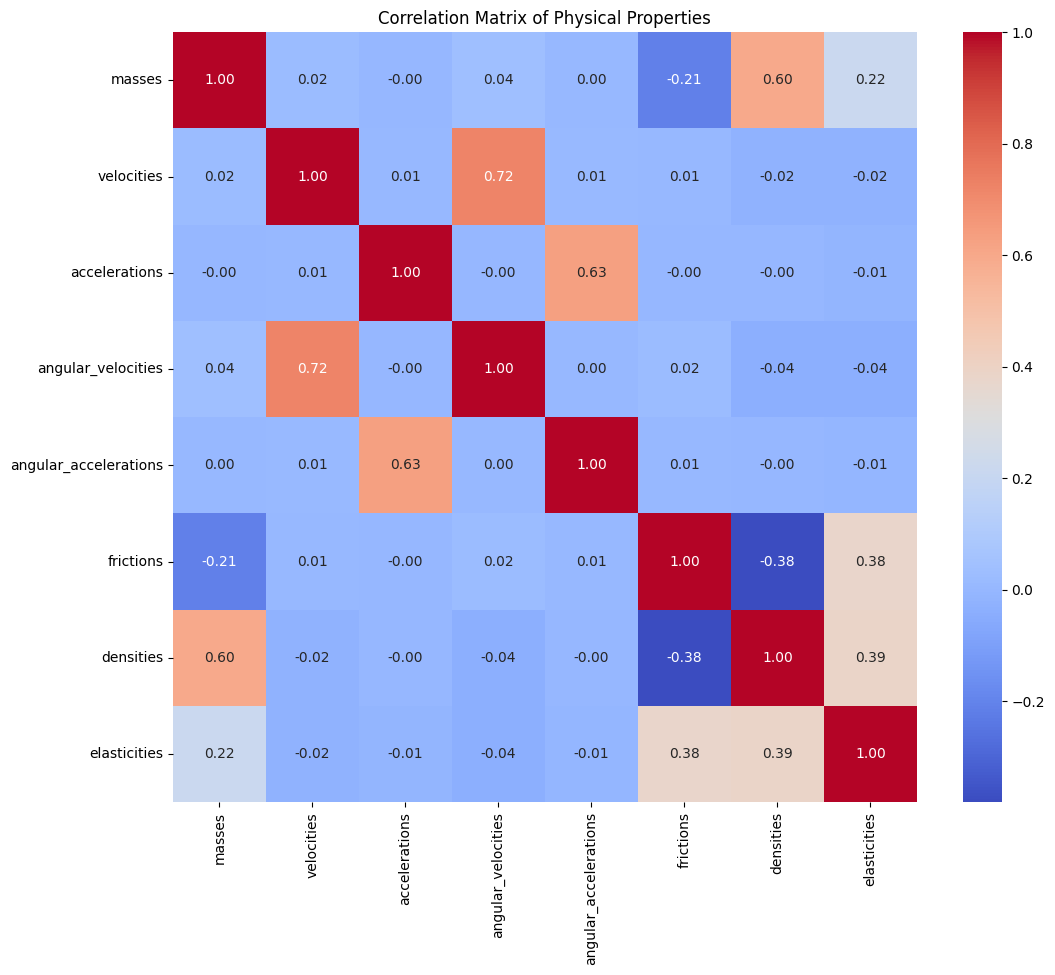

In [14]:

analyze_data(data, use_correlation=True, scale_data=True)  

max_length 101430
key masses
key velocities
key accelerations
100625
key angular_velocities
key angular_accelerations
100625
key frictions
key densities
key elasticities


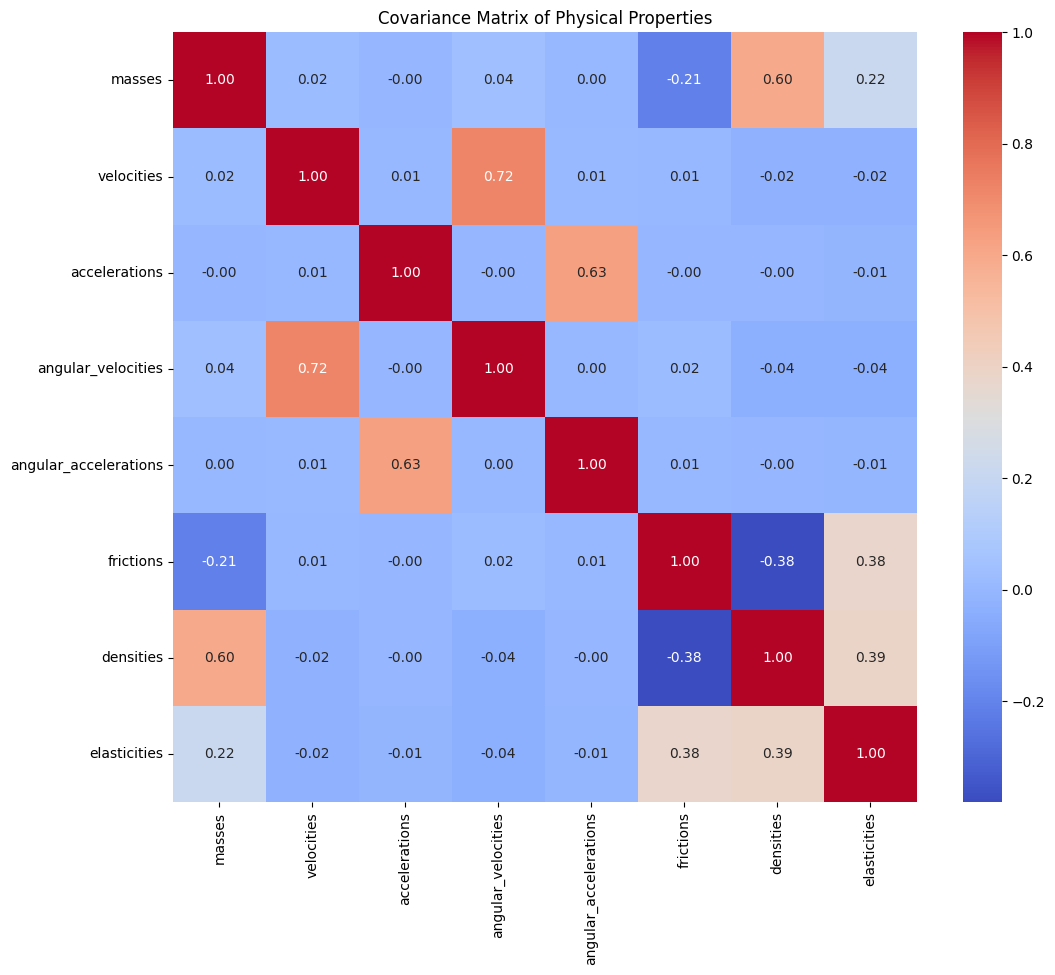

In [15]:
analyze_data(data, use_correlation=False, scale_data=True)  
